Decision trees

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 8)

In [3]:
data = pd.read_csv(
    "M:/accenture/ds-ml-training/ds-ai-assignments-maksym-bondar/weeks/week1/data/day.csv"
)
print("Dataset size:", data.shape)
data.head()


Dataset size: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:

threshold = data["cnt"].median()
print("Median cnt:", threshold)

data["high_demand"] = (data["cnt"] > threshold).astype(int)
data["high_demand"].value_counts()

Median cnt: 4548.0


high_demand
0    366
1    365
Name: count, dtype: int64

high_demand = 1 is high usage days

high_demand = 0 is lower usage days

In [5]:
categorical_columns = [
    "season",    
    "yr",        
    "mnth",     
    "holiday",   
    "weekday",   
    "workingday",
    "weathersit" 
]

drop_columns = [
    "dteday",     # not useful 
    "casual",   # casual + registered
    "registered",
    "cnt", # used already to create the target
    "high_demand" # target
]

numerical_columns = [
    c for c in data.columns
    if c not in categorical_columns + drop_columns
]

print("Categorical features:", categorical_columns)
print("Numerical features:", numerical_columns)


Categorical features: ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
Numerical features: ['instant', 'temp', 'atemp', 'hum', 'windspeed']


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   instant      731 non-null    int64  
 1   dteday       731 non-null    object 
 2   season       731 non-null    int64  
 3   yr           731 non-null    int64  
 4   mnth         731 non-null    int64  
 5   holiday      731 non-null    int64  
 6   weekday      731 non-null    int64  
 7   workingday   731 non-null    int64  
 8   weathersit   731 non-null    int64  
 9   temp         731 non-null    float64
 10  atemp        731 non-null    float64
 11  hum          731 non-null    float64
 12  windspeed    731 non-null    float64
 13  casual       731 non-null    int64  
 14  registered   731 non-null    int64  
 15  cnt          731 non-null    int64  
 16  high_demand  731 non-null    int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 97.2+ KB


In [7]:
data_model = pd.concat(
    [
        data[numerical_columns],
        pd.get_dummies(data[categorical_columns], drop_first=False)
    ],
    axis=1
)

X = data_model
y = data["high_demand"]

X.shape, y.shape


((731, 12), (731,))

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=17,
    stratify=y
)

X_train.shape, X_test.shape


((511, 12), (220, 12))

Decision tree (no tuning, max_depth=3)

In [11]:
tree = DecisionTreeClassifier(max_depth=3, random_state=17)
tree.fit(X_train, y_train)

tree_preds = tree.predict(X_test)
acc_tree = accuracy_score(y_test, tree_preds)
print("Decision Tree (depth=3) accuracy:", acc_tree)


Decision Tree (depth=3) accuracy: 0.8363636363636363


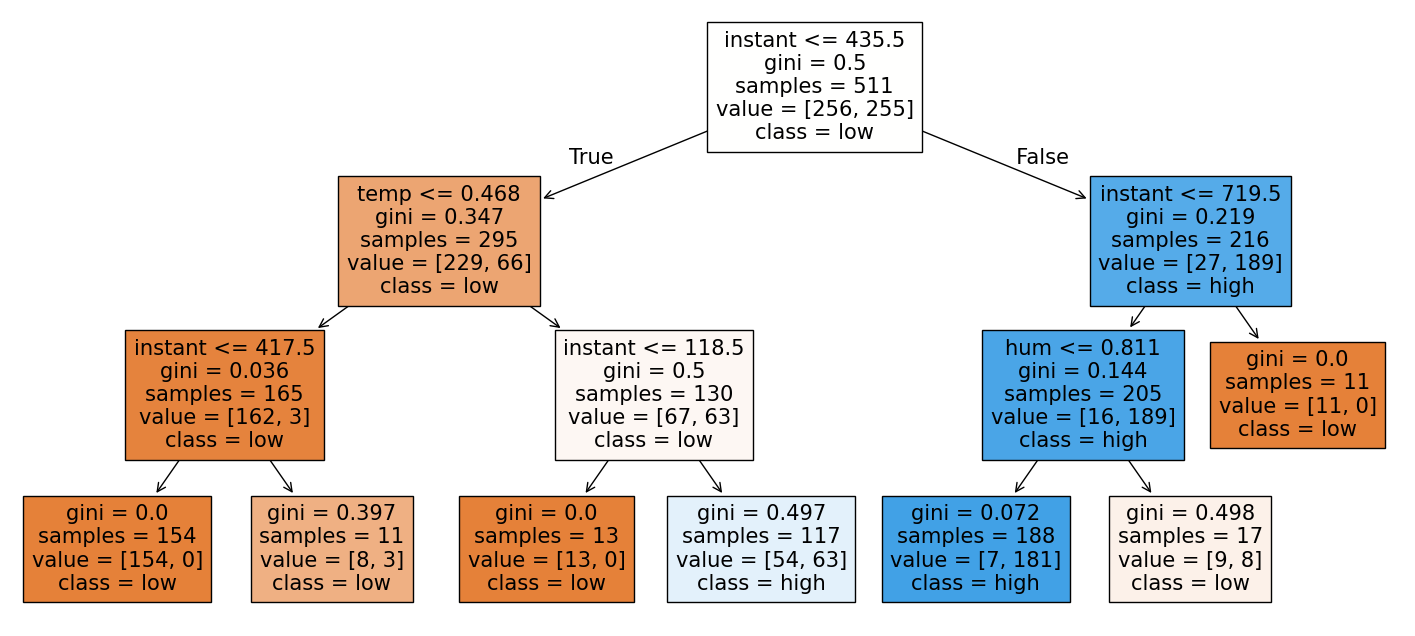

In [12]:
plt.figure(figsize=(18, 8))
plot_tree(
    tree,
    feature_names=X_train.columns,
    class_names=["low", "high"],
    filled=True,
    max_depth=3
)
plt.show()


Tuned Decision Tree (GridSearchCV over max_depth)

In [13]:
tree_params = {"max_depth": range(2, 11)}

best_tree_cv = GridSearchCV(
    DecisionTreeClassifier(random_state=17),
    tree_params,
    cv=5
)

best_tree_cv.fit(X_train, y_train)

print("Best params:", best_tree_cv.best_params_)
print("Best CV score:", best_tree_cv.best_score_)


Best params: {'max_depth': 6}
Best CV score: 0.8747001713306682


In [15]:
best_depth = best_tree_cv.best_params_["max_depth"]

tuned_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=17)
tuned_tree.fit(X_train, y_train)

tuned_tree_preds = tuned_tree.predict(X_test)
acc_tuned_tree = accuracy_score(y_test, tuned_tree_preds)
print("Tuned Decision Tree (depth={}) accuracy: {:.4f}".format(
    best_depth, acc_tuned_tree
))


Tuned Decision Tree (depth=6) accuracy: 0.8818


Random Forest

In [16]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=17,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
acc_rf = accuracy_score(y_test, rf_preds)
print("Random Forest (100 trees) accuracy:", acc_rf)


Random Forest (100 trees) accuracy: 0.9136363636363637


cross-validation on train:

In [17]:
cv_scores = cross_val_score(rf, X_train, y_train, cv=3)
print("RF CV scores:", cv_scores)
print("RF CV mean:", cv_scores.mean())

RF CV scores: [0.89473684 0.84705882 0.87647059]
RF CV mean: 0.8727554179566562


Tuned Random Forest (GridSearchCV)

In [18]:
forest_params = {
    "max_depth": range(10, 16),
    "max_features": range(5, X_train.shape[1], 5)
}

best_forest_cv = GridSearchCV(
    RandomForestClassifier(
        n_estimators=10,
        random_state=17,
        n_jobs=-1
    ),
    forest_params,
    cv=3,
    verbose=1
)

best_forest_cv.fit(X_train, y_train)

print("Best forest params:", best_forest_cv.best_params_)
print("Best forest CV score:", best_forest_cv.best_score_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best forest params: {'max_depth': 10, 'max_features': 10}
Best forest CV score: 0.8688682490540076


tuned forest on test:

In [ ]:
best_forest = best_forest_cv.best_estimator_

tuned_rf_preds = best_forest.predict(X_test)
acc_tuned_rf = accuracy_score(y_test, tuned_rf_preds)
print("Tuned Random Forest accuracy:", acc_tuned_rf)

Tuned Random Forest accuracy: 0.9045454545454545


Decision Tree Regressor on cnt

In [26]:
y = data["cnt"] # targer for regression

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=17
)

In [ ]:
reg_tree = DecisionTreeRegressor(max_depth=5, random_state=17)
reg_tree.fit(X_train, y_train)


y_pred = reg_tree.predict(X_test)

In [ ]:
mse = np.sum((y_test - y_pred) ** 2) / len(y_test)
mse

np.float64(835756.020653167)

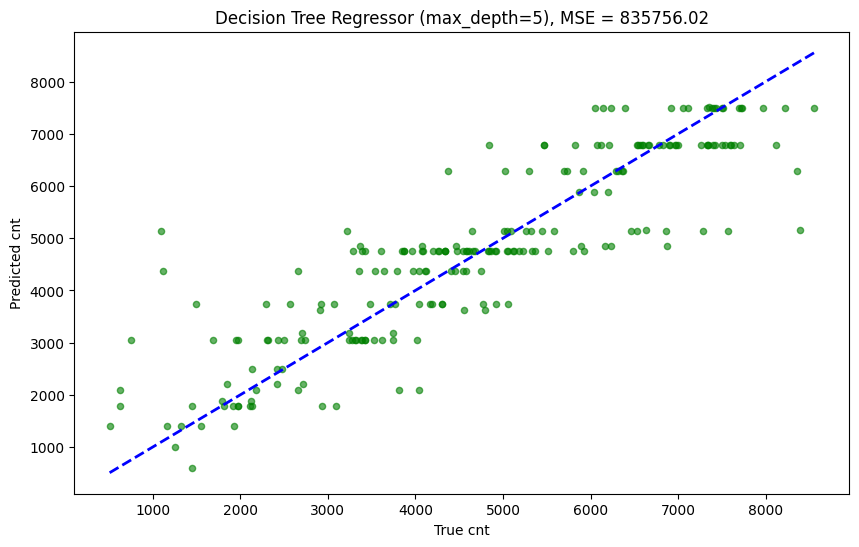

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, c="g", s=20, alpha=0.6)
plt.xlabel("True cnt")
plt.ylabel("Predicted cnt")
plt.title(f"Decision Tree Regressor (max_depth=5), MSE = {mse:.2f}")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "b--", linewidth=2)
plt.show()


k-NN classifier

In [8]:
X = data_model
y = data["high_demand"]

In [34]:
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.3, random_state=17
)

In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_holdout_scaled = scaler.transform(X_holdout)

In [39]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_holdout_scaled)
acc_knn = accuracy_score(y_holdout, knn_pred)
acc_knn

0.8681818181818182

Tune k using GridSearchCV

In [44]:
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

knn_params = {"knn__n_neighbors": range(1, 15)}

knn_grid = GridSearchCV(knn_pipe, knn_params, cv=5, n_jobs=-1, verbose=True)
knn_grid.fit(X_train, y_train)

knn_grid.best_params_, knn_grid.best_score_


Fitting 5 folds for each of 14 candidates, totalling 70 fits


({'knn__n_neighbors': 9}, np.float64(0.8629354654483151))

In [45]:
knn_tuned_pred = knn_grid.predict(X_holdout)
acc_knn_tuned = accuracy_score(y_holdout, knn_tuned_pred)
acc_knn_tuned

0.8590909090909091